In [1]:
pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\hanki\OneDrive\Desktop\Buisness_Sales_Performance_Analysis\data\SuperStore_Sales_Dataset.csv")

# Show dataset info
print(df.info())

# Check missing values
print(df.isnull().sum())

# Convert dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Remove unnecessary columns
df = df.drop(["ind1","ind2"], axis=1)

# Check duplicates
df = df.drop_duplicates()

# Save cleaned dataset
df.to_csv("clean_superstore_sales.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Row ID+O6G3A1:R6  5901 non-null   int64  
 1   Order ID          5901 non-null   object 
 2   Order Date        5901 non-null   object 
 3   Ship Date         5901 non-null   object 
 4   Ship Mode         5901 non-null   object 
 5   Customer ID       5901 non-null   object 
 6   Customer Name     5901 non-null   object 
 7   Segment           5901 non-null   object 
 8   Country           5901 non-null   object 
 9   City              5901 non-null   object 
 10  State             5901 non-null   object 
 11  Region            5901 non-null   object 
 12  Product ID        5901 non-null   object 
 13  Category          5901 non-null   object 
 14  Sub-Category      5901 non-null   object 
 15  Product Name      5901 non-null   object 
 16  Sales             5901 non-null   float64


ValueError: time data "14-01-2019" doesn't match format "%m-%d-%Y", at position 10. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [4]:
total_sales = df["Sales"].sum()
print("Total Sales:", total_sales)

Total Sales: 1565804.3232


In [5]:
category_sales = df.groupby("Category")["Sales"].sum()
print(category_sales)

Category
Furniture          451508.6452
Office Supplies    643707.6870
Technology         470587.9910
Name: Sales, dtype: float64


In [6]:
region_sales = df.groupby("Region")["Sales"].sum()
print(region_sales)

Region
Central    341007.5242
East       450234.6660
South      252121.0810
West       522441.0520
Name: Sales, dtype: float64


Matplotlib is building the font cache; this may take a moment.


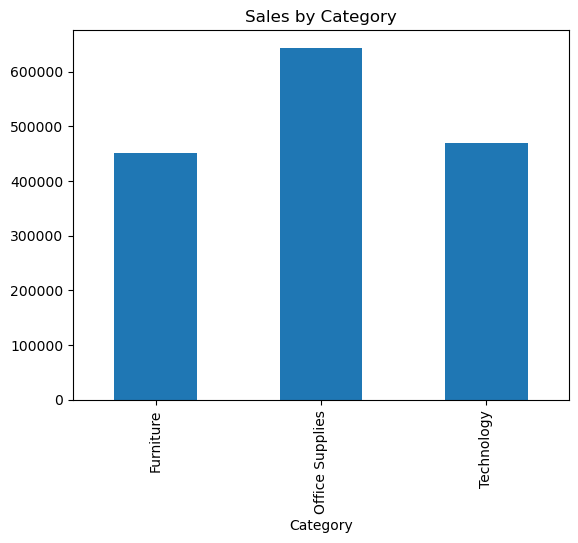

In [7]:
import matplotlib.pyplot as plt

category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.show()